# **EXPERIMENT-7** -Bank datset

**AIM**:To implement and evaluate Support Vector Machine (SVM) models to predict whether a customer will subscribe to a term deposit (deposit = yes/no) using the Bank Marketing dataset, and analyze performance using evaluation metrics.

**Brief Introduction to SVM:**
Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression.It is mainly used for classification problems.

**How it works (simple idea):**
* SVM tries to find a best separating line (or hyperplane).
* This line separates two classes with maximum margin.
* Only some important data points affect this boundary.
* These points are called Support Vectors.

**SVM can handle:**
* Linear separation → using Linear Kernel
* Non-linear separation → using RBF or Polynomial kernel

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Dataset Loading and Exploration**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
bank_data = pd.read_csv('/content/drive/MyDrive/Datasets/bank.csv')
print("Shape:", bank_data.shape)
print("\nFirst 2 Rows:\n",bank_data.head(2))
print("\nDuplicated:", bank_data.duplicated().sum())
print("\nMissing Values:\n", bank_data.isna().sum())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (11162, 17)

First 2 Rows:
    age     job  marital  education default  balance housing loan  contact  \
0   59  admin.  married  secondary      no     2343     yes   no  unknown   
1   56  admin.  married  secondary      no       45      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  

Duplicated: 0

Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64


**Data Preprocessing**

In [ ]:
bank_data = bank_data.drop_duplicates()

**Encoding Categorical Features:**
* Bank dataset contains text columns like job, marital, education, etc.
* SVM cannot work with text, so we convert them into numeric form.

In [ ]:
bank_data = pd.get_dummies(bank_data, drop_first=True)

**Feature–Label Separation**

In [ ]:
X = bank_data.drop("deposit_yes", axis=1)
Y = bank_data["deposit_yes"]

**Train–Test Split and Feature Scaling**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, Y_train, Y_test = train_test_split( X, Y, test_size=0.2, random_state=42, stratify=Y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Comparison (SVC, NuSVC, LinearSVC)**

In [ ]:
from sklearn.svm import SVC, NuSVC, LinearSVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
kernels = ['linear', 'rbf', 'poly']
C_values = [0.1, 1, 10]

results = []

for kernel in kernels:
    for C in C_values:
        model = SVC(kernel=kernel, C=C, gamma='scale', probability=True)
        model.fit(X_train, Y_train)

        Y_pred = model.predict(X_test)
        Y_proba = model.predict_proba(X_test)[:,1]

        results.append([
            "SVC",
            kernel,
            C,
            accuracy_score(Y_test, Y_pred),
            f1_score(Y_test, Y_pred),
            roc_auc_score(Y_test, Y_proba)
        ])

results_df = pd.DataFrame(results,
columns=['Model','Kernel','C','Accuracy','F1','ROC_AUC'])

print(results_df)

  Model  Kernel     C  Accuracy        F1   ROC_AUC
0   SVC  linear   0.1  0.831169  0.821242  0.907384
1   SVC  linear   1.0  0.831617  0.821970  0.907302
2   SVC  linear  10.0  0.831169  0.821412  0.907282
3   SVC     rbf   0.1  0.836095  0.826376  0.908607
4   SVC     rbf   1.0  0.849082  0.843329  0.918739
5   SVC     rbf  10.0  0.844156  0.837383  0.910158
6   SVC    poly   0.1  0.750112  0.682232  0.900968
7   SVC    poly   1.0  0.841469  0.830297  0.914416
8   SVC    poly  10.0  0.837886  0.827947  0.897176


**Decision Boundary Visualization (2D using PCA):**

Since Bank dataset has many features, we reduce it to 2 dimensions using PCA.

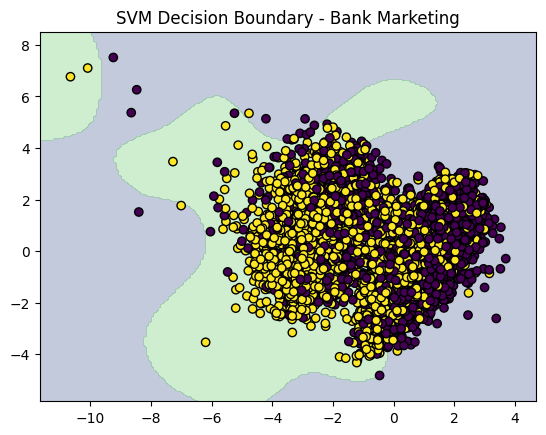

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

best_model = SVC(kernel='rbf', C=10)
best_model.fit(X_pca, Y_train)

x_min, x_max = X_pca[:,0].min()-1, X_pca[:,0].max()+1
y_min, y_max = X_pca[:,1].min()-1, X_pca[:,1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = best_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_pca[:,0], X_pca[:,1], c=Y_train, edgecolor='k')
plt.title("SVM Decision Boundary - Bank Marketing")
plt.show()

**Support Vectors:**

In [ ]:
print("Number of Support Vectors:", best_model.n_support_)

Number of Support Vectors: [3194 3199]


**Model Evaluation**

In [ ]:
from sklearn.metrics import confusion_matrix

print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

Accuracy: 0.8378862516793552

Confusion Matrix:
 [[1000  175]
 [ 187  871]]
